# Setup

In [ ]:
# !rm -rf ~/.cache/huggingface/*


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA

/content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA


In [ ]:
!pip install -U pip bitsandbytes

!pip install \
  transformers==4.38.2 \
  datasets==2.18.0 \
  accelerate==0.27.2 \
  sentencepiece \
  tqdm \
  scikit-learn \
  attrdict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 32.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 57.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 109.0 MB/s  0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.0
    Uninstalling huggingface_hub-1.4.0:
      Successfully uninstalled huggingface_hub-1.4.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
   

# (New) Sequential hops and Error Analysis

### Import

In [ ]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
from tqdm import tqdm

### Load model (quantization for faster)

In [ ]:
model_id = "google/flan-t5-xxl"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_id, torch_dtype=torch.float16, device_map="auto"
)

pipe = pipeline(
    "text2text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto",
    batch_size=8,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model-00004-of-00005.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/6.06G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
!nvidia-smi

Thu Feb 12 13:09:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             52W /  400W |   25538MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Load data

In [ ]:
df_dev = pd.read_csv("data/finance/dev.csv")
df_test = pd.read_csv("data/finance/test.csv")

TEXT_COL = "title"
TICKER_COL = "ticker"
LABEL_COL = "true_sentiment"
FINBERT_COL = "finbert_sentiment"
IN_CONTEXT_COL = "text"
EX_CONTEXT_1_COL = "external_context_1"
EX_CONTEXT_2_COL = "external_context_2"
EX_CONTEXT_3_COL = "external_context_3"

In [ ]:
# # sample only
# sample_df = df_dev.sample(100, random_state=42).reset_index(drop=True)

# full dev set
sample_df = df_dev

### Generation Helper

In [ ]:
def generate_text(prompt, max_new_tokens=64):
    output = pipe(
        prompt,
        max_new_tokens=max_new_tokens,
        truncation=True,
        do_sample=False,
        temperature=0.0,
    )
    return output[0]["generated_text"].strip()

### FinBERT

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# --- Metrics ---
accuracy = accuracy_score(sample_df["true_sentiment"], sample_df["finbert_sentiment"])
macro_f1 = f1_score(
    sample_df["true_sentiment"], sample_df["finbert_sentiment"], average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy: 0.5626
Macro F1: 0.5599


### Single Prompt
*   Dev Set: Accuracy 0.7190, Macro F1 0.7123
*   Test Set: Accuracy 0.7078, Macro F1: 0.6951



In [ ]:
# get from chatgpt paper, will fix this for evaluation purpose (72%)


def prompt_only(title, ticker):
    return f"""
Act as an expert at forex trading.
Classify the sentiment for ***{ticker}*** based only on the headline '{title}'
Answer in one token: Positive, Negative, or Neutral
""".strip()

In [ ]:
def run_prompt_batch(batch):
    prompts = [prompt_only(t, tk) for t, tk in zip(batch[TEXT_COL], batch[TICKER_COL])]
    outputs = pipe(prompts, max_new_tokens=5, truncation=True)
    batch["prompt_pred"] = [o["generated_text"].strip() for o in outputs]
    return batch

##### Evaluate in Sample/Dev Set

In [ ]:
from datasets import Dataset

hf_ds_dev = Dataset.from_pandas(sample_df)
hf_ds_dev = hf_ds_dev.map(run_prompt_batch, batched=True, batch_size=8)

df_dev = hf_ds_dev.to_pandas()

Map:   0%|          | 0/1829 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


In [ ]:
# save df_dev to csv
df_dev.to_csv("data/finance/result_dev_singleprompt.csv", index=False)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

LABELS = ["Positive", "Neutral", "Negative"]

y_true = df_dev["true_sentiment"]
y_pred = df_dev["prompt_pred"]

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print("Single Prompt Result")
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print()
print(classification_report(y_true, y_pred, labels=LABELS, digits=4))

Single Prompt Result
Accuracy: 0.7190
Macro F1: 0.7123

              precision    recall  f1-score   support

    Positive     0.6109    0.9314    0.7379       612
     Neutral     0.8101    0.4455    0.5748       651
    Negative     0.8457    0.8039    0.8243       566

    accuracy                         0.7190      1829
   macro avg     0.7556    0.7269    0.7123      1829
weighted avg     0.7545    0.7190    0.7066      1829



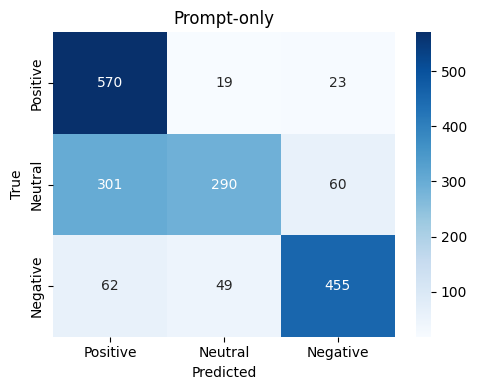

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, labels=LABELS)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS
)

plt.title("Prompt-only")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

##### Evaluate in Test Set

In [ ]:
hf_ds_test = Dataset.from_pandas(df_test)
hf_ds_test = hf_ds_test.map(run_prompt_batch, batched=True, batch_size=8)

df_test = hf_ds_test.to_pandas()

Map:   0%|          | 0/462 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

LABELS = ["Positive", "Neutral", "Negative"]

y_true = df_test["true_sentiment"]
y_pred = df_test["prompt_pred"]

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print("Single Prompt Result")
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print()
print(classification_report(y_true, y_pred, labels=LABELS, digits=4))

Single Prompt Result
Accuracy: 0.7078
Macro F1: 0.6951

              precision    recall  f1-score   support

    Positive     0.6173    0.9677    0.7538       155
     Neutral     0.7558    0.3963    0.5200       164
    Negative     0.8421    0.7832    0.8116       143

    accuracy                         0.7078       462
   macro avg     0.7384    0.7158    0.6951       462
weighted avg     0.7360    0.7078    0.6887       462



### Sequential Multi-Hop Function

* Dev Set: Accuracy 0.7310, Macro F1 0.7306
* Test Set: Accuracy 0.7143, Macro F1 0.7091



In [ ]:
# # 1-prompt-multi-hop form (old version for reference)

# def multihop_prompt(title, ticker):
#      return f"""
# Task: Financial Sentiment Analysis.
# Input Ticker: {ticker}
# Input Headline: {title}

# Analyze the sentiment by following these steps:
# 1. Identify Base Currency (BC) and Quote Currency (QC) from {ticker}.
# 2. Evaluate if {title} is Hawkish/Bullish or Dovish/Bearish for BC and QC.
# 3. Assign BC Sentiment: [Positive, Negative, or Neutral].
# 4. Assign QC Sentiment: [Positive, Negative, or Neutral].
# 5. Final Classification: Determine if the pair {ticker} will move up (Positive) or down (Negative) or go sideway (Neutral).

# """.strip()

In [ ]:
# v2
# Dev Set: Accuracy 0.7310, Macro F1 0.7306
# Test Set: Accuracy 0.7143, Macro F1 0.7091


def run_multihop_debug(title, ticker):
    base = ticker[:3]
    quote = ticker[3:]

    # ---------------------------
    # Hop 1 – FX Insight
    # ---------------------------
    hop1_prompt = f"""
You are an FX signal analyst.

Pair: {ticker}
Headline: {title}

For BOTH currencies in the pair, determine if the headline implies:

Upward pressure
Downward pressure
No clear pressure

Consider:
• Technical language (breaks, trims, downside, bulls, bears, resistance, floor)
• Policy tone (too fast, cautious, tightening, easing)
• Yield movement
• Risk language (woes, concerns, uncertainty)
• Sustainability language (unsustainable, fading)

For each detected pressure, state:
• Currency affected
• Direction of pressure (upward / downward)

If absolutely no directional pressure is implied, state:
No directional pressure detected.

Do NOT classify sentiment.
Return 1–3 short bullet points.
""".strip()

    hop1 = generate_text(hop1_prompt, 40).strip()

    # ---------------------------
    # Hop 2 – Base Currency Sentiment
    # ---------------------------
    hop2_prompt = f"""
Task: Financial Sentiment Analysis.

Input Ticker: {ticker}
Input Headline: {title}

Base Currency: {base}

Is the headline Hawkish/Bullish, Dovish/Bearish, or Neutral for {base}?
If unclear, use directional signals: {hop1}

Answer ONLY:
Positive
Negative
Neutral
""".strip()

    hop2 = generate_text(hop2_prompt, 8).strip()

    # ---------------------------
    # Hop 3 – Quote Currency Sentiment
    # ---------------------------
    hop3_prompt = f"""
Task: Financial Sentiment Analysis.

Input Ticker: {ticker}
Input Headline: {title}

Quote Currency: {quote}

Is the headline Hawkish/Bullish, Dovish/Bearish, or Neutral for {quote}?
If unclear, just return Neutral.

Answer ONLY:
Positive
Negative
Neutral
""".strip()

    hop3 = generate_text(hop3_prompt, 8).strip()

    # ---------------------------
    # Hop 4 – Final Classification
    # ---------------------------
    hop4_prompt = f"""
Task: Financial Sentiment Analysis.

Ticker: {ticker}

BC Sentiment: {hop2}
QC Sentiment: {hop3}

If BC Positive and QC not Positive → Positive
If BC Negative and QC not Negative → Negative
If both same or both Neutral → Neutral

Return ONLY one token:
Positive
Negative
Neutral
""".strip()

    final = generate_text(hop4_prompt, 8).strip().split()[0]

    return hop1, hop2, hop3, final

##### Evaluate in Sample/Dev Set

In [ ]:
results = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    title = row["title"]
    ticker = row["ticker"]
    text = row["text"]

    hop1, hop2, hop3, final = run_multihop_debug(title, ticker)

    results.append(
        {
            "title": title,
            "ticker": ticker,
            "true_sentiment": row["true_sentiment"],
            "hop1_bc_sentiment": hop1,
            "hop2_bc_sentiment": hop2,
            "hop3_qc_sentiment": hop3,
            "final_prediction": final,
        }
    )

debug_df = pd.DataFrame(results)

  0%|          | 0/1829 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 1829/1829 [20:02<00:00,  1.52it/s]


In [ ]:
# debug_df
debug_df[debug_df["true_sentiment"] != debug_df["final_prediction"]]

,title,ticker,true_sentiment,hop1_bc_sentiment,hop2_bc_sentiment,hop3_qc_sentiment,final_prediction
0,EURCHF Bias would be for stronger Franc but wa...,EURCHF,Negative,Upward pressure,Neutral,Neutral,Neutral
2,Does a jump in EURCHF point to a break above 1...,EURCHF,Neutral,Upward pressure,Positive,Neutral,Positive
12,USDJPY to see a sustained break below 12727 af...,USDJPY,Negative,No clear pressure,Neutral,Neutral,Neutral
20,EURUSD hovers around multiweek lows below 10600,EURUSD,Negative,No clear pressure,Neutral,Neutral,Neutral
21,GBPUSD struggles to justify Brexit hopes aroun...,GBPUSD,Negative,No clear pressure,Neutral,Neutral,Neutral
...,...,...,...,...,...,...,...
1797,RBA Board expects that some further tightening...,AUDUSD,Positive,Upward pressure,Neutral,Neutral,Neutral
1798,GBPUSD nears 12500 as doubts over Feds role in...,GBPUSD,Positive,Downward pressure,Negative,Neutral,Negative
1800,Forex Today Dollar weakens ahead of Fed decision,EURUSD,Positive,Downward pressure,Negative,Negative,Negative
1811,RBAs Lowe We will do what is necessary to brin...,AUDUSD,Positive,No directional pressure detected,Neutral,Neutral,Neutral


In [ ]:
# save debug_df to csv
debug_df.to_csv("data/finance/result_dev_multihop.csv", index=False)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# --- Metrics ---
accuracy = accuracy_score(debug_df["true_sentiment"], debug_df["final_prediction"])
macro_f1 = f1_score(
    debug_df["true_sentiment"], debug_df["final_prediction"], average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy: 0.7310
Macro F1: 0.7306



Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.66      0.77       566
     Neutral       0.72      0.61      0.66       651
    Positive       0.65      0.93      0.77       612

    accuracy                           0.73      1829
   macro avg       0.76      0.73      0.73      1829
weighted avg       0.76      0.73      0.73      1829



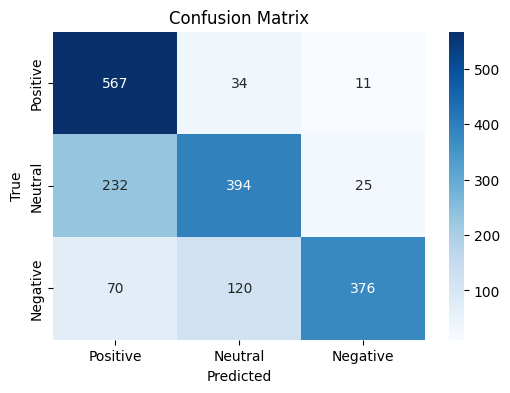

In [ ]:
print("\nClassification Report:\n")
print(classification_report(debug_df["true_sentiment"], debug_df["final_prediction"]))

labels = ["Positive", "Neutral", "Negative"]

cm = confusion_matrix(
    debug_df["true_sentiment"], debug_df["final_prediction"], labels=labels
)

# draw confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

##### Evaluate in Test Set

In [ ]:
results = []

for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    title = row["title"]
    ticker = row["ticker"]

    hop1, hop2, hop3, final = run_multihop_debug(title, ticker)

    results.append(
        {
            "title": title,
            "ticker": ticker,
            "true_sentiment": row["true_sentiment"],
            "hop1_bc_sentiment": hop1,
            "hop2_bc_sentiment": hop2,
            "hop3_qc_sentiment": hop3,
            "final_prediction": final,
        }
    )

debug_df_test = pd.DataFrame(results)

In [ ]:
debug_df_test.head()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# --- Metrics ---
accuracy = accuracy_score(
    debug_df_test["true_sentiment"], debug_df_test["final_prediction"]
)
macro_f1 = f1_score(
    debug_df_test["true_sentiment"], debug_df_test["final_prediction"], average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

In [ ]:
print("\nClassification Report:\n")
print(
    classification_report(
        debug_df_test["true_sentiment"], debug_df_test["final_prediction"]
    )
)

labels = ["Positive", "Neutral", "Negative"]

cm = confusion_matrix(
    debug_df_test["true_sentiment"], debug_df_test["final_prediction"], labels=labels
)

# draw confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### Hybrid

*   Dev Set: Accuracy 0.7501, Macro F1 0.7506
*   Test Set: Accuracy 0.7338, Macro F1 0.7285



In [ ]:
import re


def run_fx_pipeline(title, ticker):
    base = ticker[:3]
    quote = ticker[3:]

    # -------------------------------------------------
    # STEP 0 — Detect Headline Type
    # -------------------------------------------------
    if re.search(rf"\b{ticker}\b", title):
        mode = "direct"
    else:
        mode = "indirect"

    # =================================================
    # PATH 1 — DIRECT (Single-Step Classification)
    # =================================================
    if mode == "direct":
        direct_prompt = f"""
You are classifying FX headline sentiment.

Here are labeled examples from this dataset:

Example 1:
Headline: EURUSD trims gains near 10650
Label: Negative

Example 2:
Headline: GBPUSD recovers a few pips from daily low
Label: Neutral

Example 3:
Headline: EURUSD breaks above 11000 decisively
Label: Positive

Now classify:

Pair: {ticker}
Headline: {title}

Return ONLY:
Positive
Negative
Neutral
""".strip()

        raw = generate_text(direct_prompt, 8).strip()
        prediction = raw.split()[0]

        if prediction not in ["Positive", "Negative", "Neutral"]:
            prediction = "Neutral"

        return {
            "mode": "direct",
            "hop1": None,
            "hop2_bc": None,
            "hop3_qc": None,
            "final": prediction,
        }

    # =================================================
    # PATH 2 — INDIRECT (Your v3 Multi-hop)
    # =================================================

    # ---------------------------
    # Hop 1 – FX Insight
    # ---------------------------
    hop1_prompt = f"""
You are an FX signal analyst.

Pair: {ticker}
Headline: {title}

For BOTH currencies in the pair, determine if the headline implies:

Upward pressure
Downward pressure
No clear pressure

Consider:
• Technical language (breaks, trims, downside, bulls, bears, resistance, floor)
• Policy tone (too fast, cautious, tightening, easing)
• Yield movement
• Risk language (woes, concerns, uncertainty)
• Sustainability language (unsustainable, fading)

For each detected pressure, state:
• Currency affected
• Direction of pressure (upward / downward)

If absolutely no directional pressure is implied, state:
No directional pressure detected.

Do NOT classify sentiment.
Return 1–3 short bullet points.
""".strip()

    hop1 = generate_text(hop1_prompt, 40).strip()

    # ---------------------------
    # Hop 2 – Base Currency Sentiment
    # ---------------------------
    hop2_prompt = f"""
Task: Financial Sentiment Analysis.

Input Ticker: {ticker}
Input Headline: {title}

Base Currency: {base}

Is the headline Hawkish/Bullish, Dovish/Bearish, or Neutral for {base}?
If unclear, use directional signals: {hop1}

Answer ONLY:
Positive
Negative
Neutral
""".strip()

    hop2_raw = generate_text(hop2_prompt, 8).strip()
    hop2 = hop2_raw.split()[0]
    if hop2 not in ["Positive", "Negative", "Neutral"]:
        hop2 = "Neutral"

    # ---------------------------
    # Hop 3 – Quote Currency Sentiment
    # ---------------------------
    hop3_prompt = f"""
Task: Financial Sentiment Analysis.

Input Ticker: {ticker}
Input Headline: {title}

Quote Currency: {quote}

Is the headline Hawkish/Bullish, Dovish/Bearish, or Neutral for {quote}?
If unclear, just return Neutral.

Answer ONLY:
Positive
Negative
Neutral
""".strip()

    hop3_raw = generate_text(hop3_prompt, 8).strip()
    hop3 = hop3_raw.split()[0]
    if hop3 not in ["Positive", "Negative", "Neutral"]:
        hop3 = "Neutral"

    # ---------------------------
    # Hop 4 – Final Classification
    # ---------------------------
    hop4_prompt = f"""
Task: Financial Sentiment Analysis.

Ticker: {ticker}

BC Sentiment: {hop2}
QC Sentiment: {hop3}

If BC Positive and QC not Positive → Positive
If BC Negative and QC not Negative → Negative
If both same or both Neutral → Neutral

Return ONLY one token:
Positive
Negative
Neutral
""".strip()

    final_raw = generate_text(hop4_prompt, 8).strip()
    final = final_raw.split()[0]

    if final not in ["Positive", "Negative", "Neutral"]:
        final = "Neutral"

    return {
        "mode": "indirect",
        "hop1": hop1,
        "hop2_bc": hop2,
        "hop3_qc": hop3,
        "final": final,
    }

##### Evaluate in Sample/Dev Set

In [ ]:
results = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    title = row["title"]
    ticker = row["ticker"]

    output = run_fx_pipeline(title, ticker)

    results.append(
        {
            "mode": output["mode"],
            "title": title,
            "ticker": ticker,
            "true_sentiment": row["true_sentiment"],
            "hop1_bc_sentiment": output["hop1"],
            "hop2_bc_sentiment": output["hop2_bc"],
            "hop3_qc_sentiment": output["hop3_qc"],
            "final_prediction": output["final"],
        }
    )

debug_df = pd.DataFrame(results)

  0%|          | 0/1829 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 1829/1829 [07:42<00:00,  3.95it/s]


In [ ]:
debug_df[debug_df["true_sentiment"] != debug_df["final_prediction"]]

,mode,title,ticker,true_sentiment,hop1_bc_sentiment,hop2_bc_sentiment,hop3_qc_sentiment,final_prediction
0,direct,EURCHF Bias would be for stronger Franc but wa...,EURCHF,Negative,None,None,None,Neutral
2,direct,Does a jump in EURCHF point to a break above 1...,EURCHF,Neutral,None,None,None,Positive
12,direct,USDJPY to see a sustained break below 12727 af...,USDJPY,Negative,None,None,None,Positive
23,indirect,Forex Today Fed’s hawkishness boosts the US Do...,EURUSD,Negative,Upward pressure,Positive,Positive,Positive
24,indirect,Rishi Sunak forced to ‘pause’ Protocol deal,GBPUSD,Negative,No directional pressure detected,Neutral,Neutral,Neutral
...,...,...,...,...,...,...,...,...
1777,direct,There is a risk that the hawkish ECB sends EUR...,EURUSD,Neutral,None,None,None,Positive
1788,indirect,Forex Today Dollar slides as Fed delivers as e...,EURUSD,Positive,Downward pressure,Negative,Negative,Negative
1797,indirect,RBA Board expects that some further tightening...,AUDUSD,Positive,Upward pressure,Neutral,Neutral,Neutral
1800,indirect,Forex Today Dollar weakens ahead of Fed decision,EURUSD,Positive,Downward pressure,Negative,Negative,Negative


In [ ]:
# save debug_df to csv
debug_df.to_csv("data/finance/result_dev_hybrid.csv", index=False)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# --- Metrics ---
accuracy = accuracy_score(debug_df["true_sentiment"], debug_df["final_prediction"])
macro_f1 = f1_score(
    debug_df["true_sentiment"], debug_df["final_prediction"], average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy: 0.7501
Macro F1: 0.7506



Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.73      0.81       566
     Neutral       0.76      0.60      0.67       651
    Positive       0.66      0.93      0.77       612

    accuracy                           0.75      1829
   macro avg       0.78      0.75      0.75      1829
weighted avg       0.77      0.75      0.75      1829



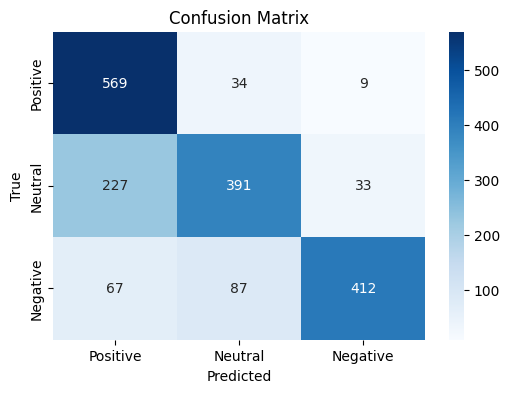

In [ ]:
print("\nClassification Report:\n")
print(classification_report(debug_df["true_sentiment"], debug_df["final_prediction"]))

labels = ["Positive", "Neutral", "Negative"]

cm = confusion_matrix(
    debug_df["true_sentiment"], debug_df["final_prediction"], labels=labels
)

# draw confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

##### Evaluate in Test Set

In [ ]:
results = []

for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    title = row["title"]
    ticker = row["ticker"]

    output = run_fx_pipeline(title, ticker)

    results.append(
        {
            "mode": output["mode"],
            "title": title,
            "ticker": ticker,
            "true_sentiment": row["true_sentiment"],
            "hop1_bc_sentiment": output["hop1"],
            "hop2_bc_sentiment": output["hop2_bc"],
            "hop3_qc_sentiment": output["hop3_qc"],
            "final_prediction": output["final"],
        }
    )

debug_df_test = pd.DataFrame(results)

  0%|          | 0/462 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 462/462 [02:05<00:00,  3.68it/s]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# --- Metrics ---
accuracy = accuracy_score(
    debug_df_test["true_sentiment"], debug_df_test["final_prediction"]
)
macro_f1 = f1_score(
    debug_df_test["true_sentiment"], debug_df_test["final_prediction"], average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy: 0.7338
Macro F1: 0.7285



Classification Report:

              precision    recall  f1-score   support

    Negative       0.87      0.73      0.79       143
     Neutral       0.73      0.52      0.61       164
    Positive       0.66      0.97      0.79       155

    accuracy                           0.73       462
   macro avg       0.75      0.74      0.73       462
weighted avg       0.75      0.73      0.72       462



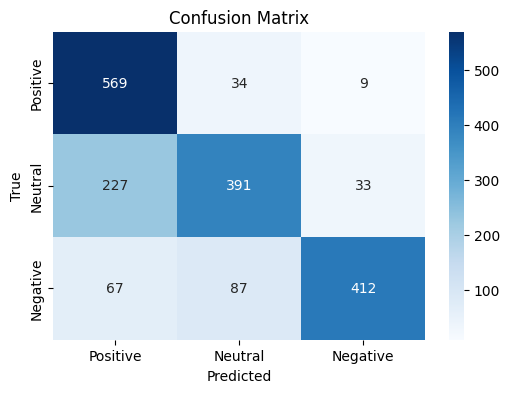

In [ ]:
print("\nClassification Report:\n")
print(
    classification_report(
        debug_df_test["true_sentiment"], debug_df_test["final_prediction"]
    )
)

labels = ["Positive", "Neutral", "Negative"]

cm = confusion_matrix(
    debug_df["true_sentiment"], debug_df["final_prediction"], labels=labels
)

# draw confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()